In [10]:
#%pip install pandas numpy matplotlib seaborn scipy scikit-learn ipywidgets imbalanced-learn xgboost

In [11]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from math import pi
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.model_selection import learning_curve

sns.set_theme(style="whitegrid")

In [12]:
# --- CONFIGURATION ---
DATA_DIR = r"C:\Users\ahmed\OneDrive - Arab Academy for Science and Technology\Desktop\RQDS"
TARGET_COLUMNS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'accel_mag']

# TIME MANAGEMENT: Car might be stationary for the first few seconds
SAMPLING_RATE = 100 
IGNORE_FIRST_N_SECONDS = 2.0  
ROWS_TO_DROP = int(IGNORE_FIRST_N_SECONDS * SAMPLING_RATE)

# Map prefix codes to actual descriptive road conditions
LABEL_MAP = {
    'RB': 'road_bump',
    'RR': 'rough_road',
    'SR': 'smooth_road'
}
print(f" Libraries loaded. Set to ignore the first {IGNORE_FIRST_N_SECONDS} seconds of every file.")

 Libraries loaded. Set to ignore the first 2.0 seconds of every file.


In [13]:
def butter_lowpass_filter(data, cutoff=20.0, fs=100.0, order=4):
    if len(data) <= order * 3: return data
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low', analog=False)
    return filtfilt(b, a, data)

def extract_features(window_df):
    features = {}
    
    for col in TARGET_COLUMNS:
        if col not in window_df.columns: continue
        data = window_df[col].values
        
        # 1. Standard Physics & Shape
        features[f'{col}_mean'] = np.mean(data)
        features[f'{col}_std'] = np.std(data)
        features[f'{col}_max'] = np.max(data)
        features[f'{col}_min'] = np.min(data)
        features[f'{col}_skew'] = skew(data)
        features[f'{col}_kurtosis'] = kurtosis(data)
        
        # 2. Jerk (The Snap/Shock)
        jerk = np.diff(data)
        if len(jerk) > 0:
            features[f'{col}_jerk_max'] = np.max(np.abs(jerk))
            features[f'{col}_jerk_mean'] = np.mean(np.abs(jerk))
            
        # 3. Fast Fourier Transform (Vibration & Shockwave)
        freq_data = np.abs(np.fft.fft(data))
        if len(freq_data) > 1:
            features[f'{col}_fft_peak'] = np.max(freq_data[1:50]) 
            features[f'{col}_fft_mean'] = np.mean(freq_data[1:50])

    # 4. 3D Axis Correlation
    if all(c in window_df.columns for c in ['accel_x', 'accel_y', 'accel_z']):
        features['corr_accel_xy'] = np.corrcoef(window_df['accel_x'], window_df['accel_y'])[0, 1]
        features['corr_accel_xz'] = np.corrcoef(window_df['accel_x'], window_df['accel_z'])[0, 1]
        features['corr_accel_yz'] = np.corrcoef(window_df['accel_y'], window_df['accel_z'])[0, 1]
        
    if all(c in window_df.columns for c in ['gyro_x', 'gyro_y', 'gyro_z']):
        features['corr_gyro_xy'] = np.corrcoef(window_df['gyro_x'], window_df['gyro_y'])[0, 1]
        features['corr_gyro_xz'] = np.corrcoef(window_df['gyro_x'], window_df['gyro_z'])[0, 1]
        features['corr_gyro_yz'] = np.corrcoef(window_df['gyro_y'], window_df['gyro_z'])[0, 1]
        
    for k, v in features.items():
        if np.isnan(v): features[k] = 0.0

    return features

print("Advanced FFT & 3D DSP Math functions ready.")

Advanced FFT & 3D DSP Math functions ready.


In [14]:
all_features = []
search_pattern = os.path.join(DATA_DIR, "**", "*_Accelerometer.csv")
accel_files = glob.glob(search_pattern, recursive=True)
print(f"Found {len(accel_files)} Accelerometer files. Processing...\n")

for accel_path in accel_files:
    gyro_path = accel_path.replace("Accelerometer", "Gyroscope")
    if not os.path.exists(gyro_path): continue

    filename = os.path.basename(accel_path)
    parts = filename.split('_')
    if len(parts) < 2: continue
    
    # Extract the base string like "RB1", "RR2", "SR10"
    run_prefix = parts[0].upper()
    
    # Isolate the letters (RB) and the run_id (1, 2, etc.)
    match = re.match(r'([A-Z]+)(\d*)', run_prefix)
    if not match: continue
    
    road_code = match.group(1) # 'RB', 'RR', 'SR'
    run_id = match.group(2) if match.group(2) else "Unknown" 
    
    if road_code not in LABEL_MAP: continue
    road_label = LABEL_MAP[road_code]

    try:
        accel_df = pd.read_csv(accel_path).rename(columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'})
        gyro_df = pd.read_csv(gyro_path).rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})
        
        merged_df = accel_df[['time', 'accel_x', 'accel_y', 'accel_z']].merge(
            gyro_df[['time', 'gyro_x', 'gyro_y', 'gyro_z']], on='time'
        )
        
        if len(merged_df) > ROWS_TO_DROP:
            merged_df = merged_df.iloc[ROWS_TO_DROP:].reset_index(drop=True)
        else:
            print(f"Skipping {filename}: File is too short.")
            continue
        
        for col in ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']:
            merged_df[col] = butter_lowpass_filter(merged_df[col].dropna())
        
        merged_df['accel_mag'] = np.sqrt(merged_df['accel_x']**2 + merged_df['accel_y']**2 + merged_df['accel_z']**2)
            
        # THE SLOW-MOTION SQUEEZE
        window_size, overlap = 200, 100 
        
        for start in range(0, len(merged_df) - window_size + 1, window_size - overlap):
            end = start + window_size
            window_features = extract_features(merged_df.iloc[start:end])
            window_features['road_label'] = road_label
            window_features['run_id'] = f"{road_code}{run_id}"
            all_features.append(window_features)
            
    except Exception as e:
        print(f"Error reading {filename}: {e}")

master_df = pd.DataFrame(all_features).dropna()
print(f" DATASET COMPLETE: {len(master_df)} segment windows ready for Machine Learning.")

Found 10 Accelerometer files. Processing...

 DATASET COMPLETE: 228 segment windows ready for Machine Learning.


 INITIATING ROAD QUALITY MODEL (LEAK-PROOFED)
 Found 228 data windows from 10 distinct road segments.

 Balancing training dataset using SMOTE...
 Applying Z-Score Standardization...

  INTERNAL OOB ACCURACY (Training Validate): 96.4%
 TRUE TEST SET ACCURACY (Unseen Runs):     80.0%

          ROAD QUALITY TELEMETRY DISTRIBUTIONS



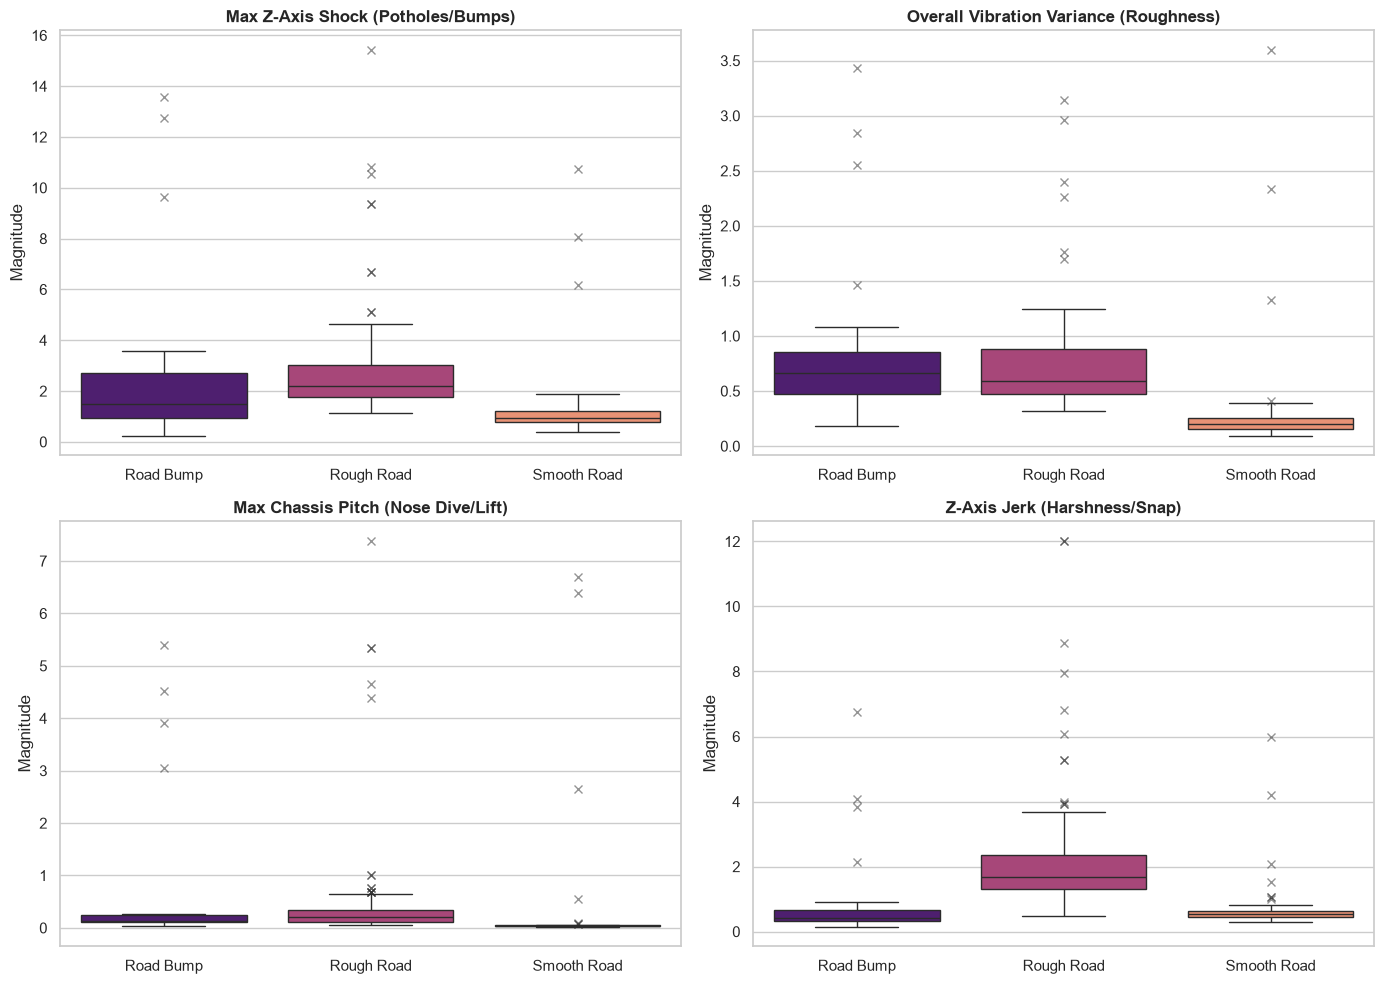

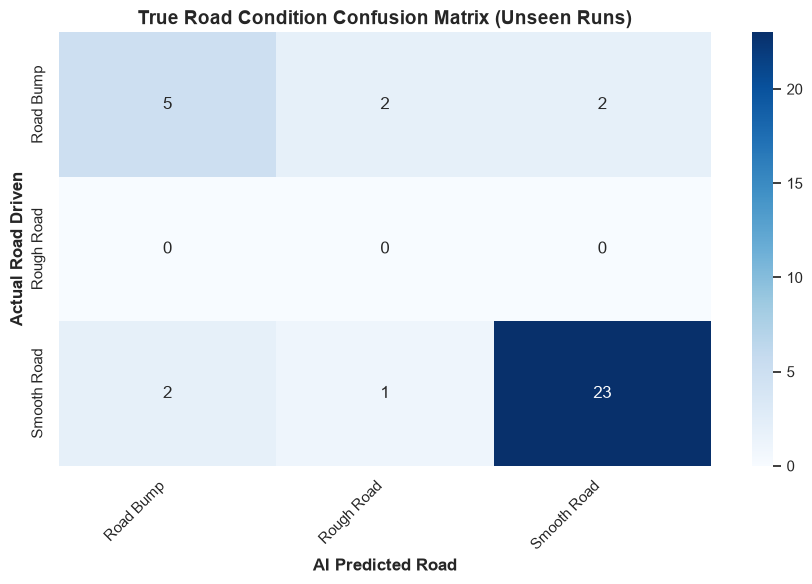

In [15]:
if len(master_df) > 0:
    from sklearn.model_selection import GroupShuffleSplit
    from imblearn.over_sampling import SMOTE
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import confusion_matrix
    from sklearn.ensemble import RandomForestClassifier
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    unique_runs = master_df['run_id'].unique()
    print(f" INITIATING ROAD QUALITY MODEL (LEAK-PROOFED)")
    print(f" Found {len(master_df)} data windows from {len(unique_runs)} distinct road segments.\n")
    
    cols_to_drop = ['road_label', 'run_id']
    X = master_df.drop(columns=cols_to_drop, errors='ignore')
    y = master_df['road_label']
    groups = master_df['run_id']
    
    # =========================================================
    # 1. THE LEAK-PROOF SPLIT (Group-Based)
    # =========================================================
    # Splits by 'run_id' so an entire run is either 100% Train or 100% Test.
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # =========================================================
    # 2. SMOTE & SCALING (Applied securely after the split)
    # =========================================================
    print(" Balancing training dataset using SMOTE...")
    smote_engine = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote_engine.fit_resample(X_train, y_train)
    
    print(" Applying Z-Score Standardization...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced) # Fit ONLY on training
    X_test_scaled = scaler.transform(X_test)                # Transform test blindly
    
    # =========================================================
    # 3. AI TRAINING ENGINE (ANTI-OVERFITTING TUNE)
    # =========================================================
    model = RandomForestClassifier(
        n_estimators=200,             # Slightly more trees for a smoother consensus
        random_state=42, 
        class_weight='balanced', 
        max_depth=10,                 # Stop trees from growing infinitely deep
        min_samples_split=20,         # Require at least 20 windows to even consider a split
        min_samples_leaf=10,          # A final decision leaf must have at least 10 samples
        max_samples=0.8,              # Each tree only gets to see 80% of the training data
        max_features='sqrt',          # Standard feature randomization
        oob_score=True
    )
    model.fit(X_train_scaled, y_train_balanced)
    
    print(f"\n  INTERNAL OOB ACCURACY (Training Validate): {model.oob_score_ * 100:.1f}%")
    test_predictions = model.predict(X_test_scaled)
    print(f" TRUE TEST SET ACCURACY (Unseen Runs):     {np.mean(test_predictions == y_test) * 100:.1f}%\n")
    
    # =========================================================
    # 4. BOX PLOT VIBRATION PROFILES (WARNING-FREE)
    # =========================================================
    print("============================================================")
    print("          ROAD QUALITY TELEMETRY DISTRIBUTIONS")
    print("============================================================\n")
    
    plot_metrics = {
        'accel_z_max': 'Max Z-Axis Shock (Potholes/Bumps)',
        'accel_mag_std': 'Overall Vibration Variance (Roughness)',
        'gyro_y_max': 'Max Chassis Pitch (Nose Dive/Lift)',
        'accel_z_jerk_max': 'Z-Axis Jerk (Harshness/Snap)'
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, (col, title) in enumerate(plot_metrics.items()):
        sns.boxplot(
            data=master_df, 
            x='road_label', 
            y=col, 
            ax=axes[i], 
            hue='road_label',      # FIX 1: Explicitly set the hue
            palette='magma',
            legend=False,          # FIX 1: Turn off the redundant legend
            showfliers=True,       
            flierprops={'marker': 'x', 'color': 'red', 'alpha': 0.5}
        )
        axes[i].set_title(title, fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Magnitude')
        
        # FIX 2: Explicitly lock the tick locations before changing the labels
        axes[i].set_xticks(axes[i].get_xticks()) 
        labels = [item.get_text().replace('_', ' ').title() for item in axes[i].get_xticklabels()]
        axes[i].set_xticklabels(labels)

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 5. CONFUSION MATRIX (Forced 3x3 Grid)
    # =========================================================
    plt.figure(figsize=(9, 6))
    
    # FORCE all 3 original categories to appear, even if the test set is missing one
    all_possible_labels = sorted(master_df['road_label'].unique())
    pretty_matrix_labels = [str(label).replace('_', ' ').title() for label in all_possible_labels]
    
    cm = confusion_matrix(y_test, test_predictions, labels=all_possible_labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=pretty_matrix_labels, 
                yticklabels=pretty_matrix_labels)
    
    plt.title('True Road Condition Confusion Matrix (Unseen Runs)', fontsize=14, fontweight='bold')
    plt.xlabel('AI Predicted Road', fontweight='bold')
    plt.ylabel('Actual Road Driven', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(" Dataset is empty. Run Cell 3 & 4.")

      GLOBAL DATASET & STATISTICAL REPORT

1. GLOBAL ROAD AVERAGES
             Avg Max Z-Shock  Avg Vibration Std  Avg Pitch Spike
Road Bump               2.72               0.88             0.72
Rough Road              2.82               0.73             0.47
Smooth Road             1.25               0.29             0.24 

2. GLOBAL SAMPLE DISTRIBUTION
 -> Rough Road: 121 recorded windows
 -> Smooth Road: 79 recorded windows
 -> Road Bump: 28 recorded windows


3. RANDOM FOREST FEATURE IMPORTANCE (Top 12)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_36484\1053559068.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='magma')


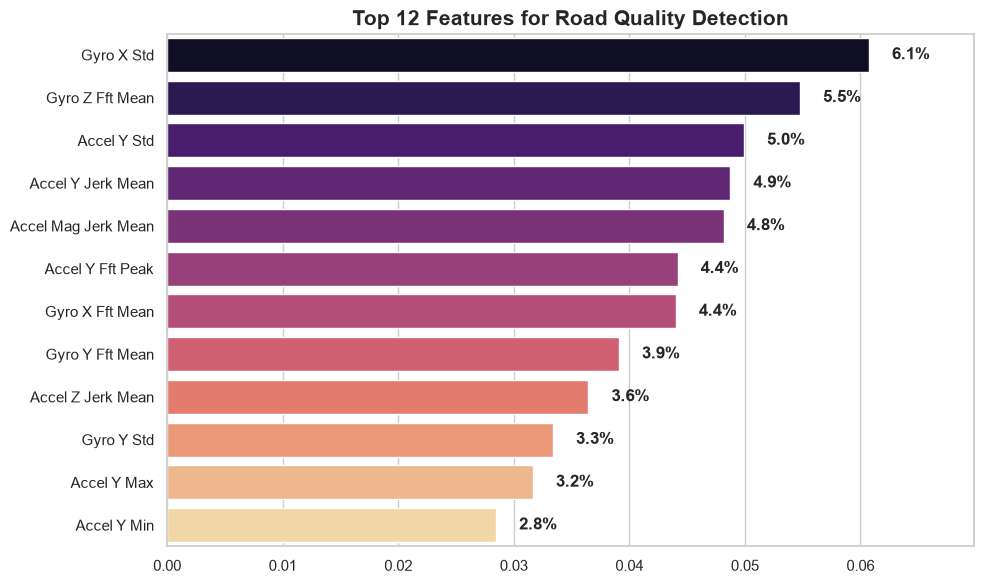

In [16]:
if 'model' in locals() and len(master_df) > 0:
    print("============================================================")
    print("      GLOBAL DATASET & STATISTICAL REPORT")
    print("============================================================\n")

    print("1. GLOBAL ROAD AVERAGES")
    global_stats = master_df.groupby('road_label')[['accel_z_max', 'accel_mag_std', 'gyro_y_max']].mean()
    global_stats.index = [str(idx).replace('_', ' ').title() for idx in global_stats.index]
    global_stats = global_stats.rename(columns={'accel_z_max': 'Avg Max Z-Shock', 'accel_mag_std': 'Avg Vibration Std', 'gyro_y_max': 'Avg Pitch Spike'})
    print(global_stats.round(2).to_string(), "\n")

    print("2. GLOBAL SAMPLE DISTRIBUTION")
    for label, count in master_df['road_label'].value_counts().items():
        print(f" -> {str(label).replace('_', ' ').title()}: {count} recorded windows")
    print("\n")

    print("3. RANDOM FOREST FEATURE IMPORTANCE (Top 12)")
    importances = model.feature_importances_
    feature_names = [col.replace('_', ' ').title() for col in X_train.columns]
    indices = np.argsort(importances)[::-1][:12]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='magma')
    plt.title('Top 12 Features for Road Quality Detection', fontsize=15, fontweight='bold')
    for index, value in enumerate(importances[indices]):
        plt.text(value + 0.002, index, f"{value*100:.1f}%", va='center', fontweight='bold')
    plt.xlim(0, max(importances[indices]) * 1.15) 
    plt.tight_layout()
    plt.show()

      INTERACTIVE ROAD CONDITION DIAGNOSTICS



interactive(children=(Dropdown(description='🛣️ Select Road:', options=('Road Bump', 'Rough Road', 'Smooth Road…


 2. Generating Leak-Proof AI Learning Curve...


C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
5 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation

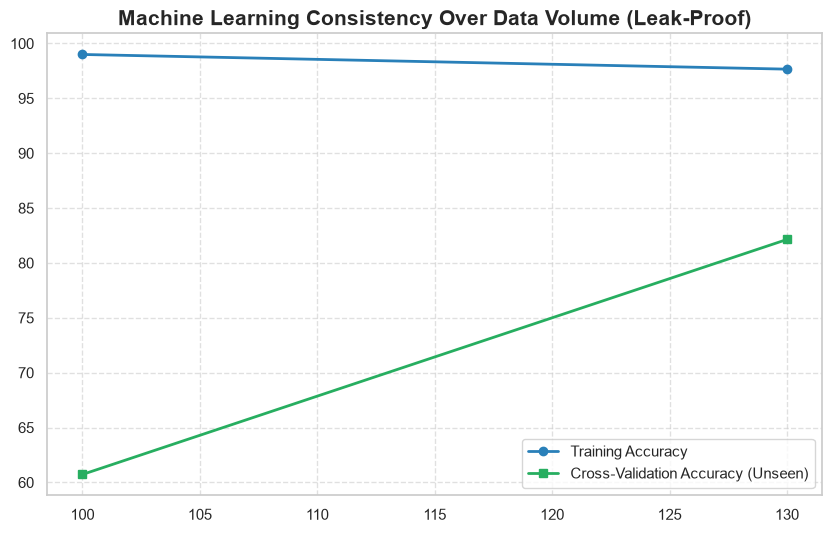

In [17]:
if 'accel_files' in locals() and 'model' in locals() and len(master_df) > 0:
    from sklearn.model_selection import GroupKFold, learning_curve
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    from sklearn.preprocessing import StandardScaler
    import ipywidgets as widgets
    from IPython.display import display
    import os
    import re
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    print("============================================================")
    print("      INTERACTIVE ROAD CONDITION DIAGNOSTICS")
    print("============================================================\n")

    all_conditions = sorted(list(set(LABEL_MAP.values())))
    pretty_conditions = [cond.replace('_', ' ').title() for cond in all_conditions]
    cond_dictionary = dict(zip(pretty_conditions, all_conditions))

    def plot_telemetry(selected_pretty_cond):
        target_cond = cond_dictionary[selected_pretty_cond]
        target_code = [k for k, v in LABEL_MAP.items() if v == target_cond][0] 
        
        run_files = {}
        for filepath in accel_files:
            parts = os.path.basename(filepath).split('_')
            if len(parts) >= 2:
                run_prefix = parts[0].upper()
                match = re.match(r'([A-Z]+)(\d*)', run_prefix)
                if match and match.group(1) == target_code:
                    run_id = f"{target_code}{match.group(2)}"
                    if run_id not in run_files and len(run_files) < 3:
                        gyro_path = filepath.replace("Accelerometer", "Gyroscope")
                        if os.path.exists(gyro_path): run_files[run_id] = (filepath, gyro_path)

        if not run_files:
            print(f"Not enough data to compare: {selected_pretty_cond}.")
            return

        num_runs = len(run_files)
        fig, axes = plt.subplots(2, num_runs, figsize=(6 * num_runs, 7), sharex=False, squeeze=False)
        fig.suptitle(f"Vehicle Telemetry (Shock/Vibration Window): {selected_pretty_cond}", fontsize=18, fontweight='bold', y=1.05)

        for i, (run_id, paths) in enumerate(sorted(run_files.items())):
            raw_accel = pd.read_csv(paths[0]).rename(columns={'x':'ax', 'y':'ay', 'z':'az'})
            raw_gyro = pd.read_csv(paths[1]).rename(columns={'x':'gx', 'y':'gy', 'z':'gz'})
            merged = raw_accel[['time', 'ax', 'ay', 'az']].merge(raw_gyro[['time', 'gx', 'gy', 'gz']], on='time')

            if len(merged) > ROWS_TO_DROP: merged = merged.iloc[ROWS_TO_DROP:].reset_index(drop=True)
            for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']: merged[col] = butter_lowpass_filter(merged[col].dropna())
                
            merged['mag'] = np.sqrt(merged['ax']**2 + merged['ay']**2 + merged['az']**2)
            
            peak_idx = merged['mag'].idxmax()
            zoom_df = merged.iloc[max(0, peak_idx - 150):min(len(merged), peak_idx + 150)].copy()
            zoom_df['time'] = zoom_df['time'] - zoom_df['time'].iloc[0]

            ax_accel = axes[0, i]
            ax_accel.plot(zoom_df['time'], zoom_df['ax'], color='#e74c3c', linewidth=2, label='X (Lateral)')
            ax_accel.plot(zoom_df['time'], zoom_df['ay'], color='#2ecc71', linewidth=2, label='Y (Longitudinal)')
            ax_accel.plot(zoom_df['time'], zoom_df['az'], color='#3498db', linewidth=2, label='Z (Vertical)')
            ax_accel.set_title(f"Run {run_id} - Suspension G-Force", fontweight='bold')
            ax_accel.grid(True, linestyle='--', alpha=0.5)
            if i == 0: ax_accel.legend()

            ax_gyro = axes[1, i]
            ax_gyro.plot(zoom_df['time'], zoom_df['gx'], color='#e74c3c', linewidth=2, label='Roll')
            ax_gyro.plot(zoom_df['time'], zoom_df['gy'], color='#2ecc71', linewidth=2, label='Pitch')
            ax_gyro.plot(zoom_df['time'], zoom_df['gz'], color='#3498db', linewidth=2, label='Yaw')
            ax_gyro.set_title(f"Run {run_id} - Chassis Rotation", fontweight='bold')
            ax_gyro.grid(True, linestyle='--', alpha=0.5)
            if i == 0: ax_gyro.legend()

        plt.tight_layout()
        plt.show()

    dropdown = widgets.Dropdown(options=pretty_conditions, value=pretty_conditions[0], description='🛣️ Select Road:')
    display(widgets.interactive(plot_telemetry, selected_pretty_cond=dropdown))

    print("\n 2. Generating Leak-Proof AI Learning Curve...")
    
    # THE PIPELINE FIX
    # This pipeline applies SMOTE and Scaling INSIDE the cross-validation loop.
    # This prevents the array length mismatch error.
    safe_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    gkf = GroupKFold(n_splits=3)
    
    train_sizes, train_scores, test_scores = learning_curve(
        safe_pipeline, 
        X_train,                        # Use the pure, original training data
        y_train,                        # Use the pure, original training labels
        groups=groups.iloc[train_idx],  # Lengths match perfectly
        cv=gkf, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        n_jobs=-1, 
        random_state=42
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1)*100, color='#2980b9', marker='o', label='Training Accuracy', linewidth=2)
    plt.plot(train_sizes, np.mean(test_scores, axis=1)*100, color='#27ae60', marker='s', label='Cross-Validation Accuracy (Unseen)', linewidth=2)
    plt.title('Machine Learning Consistency Over Data Volume (Leak-Proof)', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()